In [1]:
import os
from keras.layers import Dense,Flatten,GlobalAveragePooling2D,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from keras.models import Model
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

load a pre-trained MobileNetV2 without its fully-connected (classification) head (include_top=False).

It already contains learned weights from ImageNet (1.2M images, 1000 classes).

We unfreeze the last 60 layers, making them trainable. Everything before those layers remains frozen (weights do not update).

Early CNN layers learn generic features (edges, colors, gradients)—no need to retrain.

Later layers learn class-specific patterns, so fine-tuning them helps adapt to ASL dataset.

If we unfroze everything from the start, you would destroy the pretrained weights and overfit quickly.

In [2]:
v_net = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
for layer in v_net.layers[-60:]:
    layer.trainable = True

GAP - collapses feature maps into single vector per channel 

DENSE - learns class-specific patterns

DROPOUT - prevents overfitting by disabling 50% neurons randomly

FINAL DENSE - final prediction probability for each ASL character

In [7]:
num_classes = 26
x = v_net.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)

**Forward propagation**

Input image → convolution → ReLU → pooling… through MobileNet layers

Output → GAP → Dense layers → softmax

Model produces prediction vector like: [0.02, 0.75, 0.01 …]

**Backpropagation**

Gradient of loss is calculated layer-by-layer using chain rule.
Gradients flow backward through:

Dense layers

Dropout (ignored during backward)

last 60 layers of MobileNetV2 (because trainable=True) 
Earlier layers stay frozen (no gradient update).

**Weight update**

Adam(1e-5) performs: LR- Learning Rate

W=W−LR×gradient

LR=1e-5 is tiny to avoid destroying ImageNet weights.

Large LR would explode training.

In [8]:
model = Model(inputs=v_net.input, outputs=output)
from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

**Two important actions :**

1. preprocess_input :
Converts pixel values to MobileNet standard input Because MobileNet V2 was trained using normalized inputs.

2. Augmentations :
rotation, brightness, zoom, shear, shift, flip, channel shift

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=25,
    zoom_range=0.3,
    width_shift_range=0.25,
    height_shift_range=0.25,
    brightness_range=[0.3,1.7],
    horizontal_flip=True,
    shear_range=0.2,
    channel_shift_range=30
)

train_set = train_datagen.flow_from_directory(
    r"C:\Users\M NANDAGOPAL\OneDrive\Desktop\project_cnn\AMERICAN SIGN LANGUAGE\asl_dataset",
    target_size=(128,128),
    batch_size=25,
    class_mode='categorical',
    subset='training'
)

val_set = train_datagen.flow_from_directory(
    r"C:\Users\M NANDAGOPAL\OneDrive\Desktop\project_cnn\AMERICAN SIGN LANGUAGE\asl_dataset",
    target_size=(128,128),
    batch_size=25,
    class_mode='categorical',
    subset='validation'
)
img_size=[128,128,3]

Found 1452 images belonging to 26 classes.
Found 363 images belonging to 26 classes.


In [10]:
r=model.fit(train_set,validation_data = val_set,epochs=20)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 322s 4s/step - accuracy: 0.0468 - loss: 3.8324 - val_accuracy: 0.0551 - val_loss: 3.6162
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 154s 3s/step - accuracy: 0.0689 - loss: 3.6310 - val_accuracy: 0.0661 - val_loss: 3.5397
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 162s 3s/step - accuracy: 0.0744 - loss: 3.4741 - val_accuracy: 0.0716 - val_loss: 3.4335
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.1074 - loss: 3.2870 - val_accuracy: 0.0716 - val_loss: 3.3301
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.1047 - loss: 3.1588 - val_accuracy: 0.1185 - val_loss: 3.1869
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.1384 - loss: 3.0472 - val_accuracy: 0.1322 - val_loss: 3.0884
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - accuracy: 0.1894 - loss: 2.9101 - val_accuracy: 0.1846 - val_loss: 2.9911
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.2059 - loss: 2.7380 - val_accuracy: 0.1736 - v

In [12]:
r2=model.fit(train_set,validation_data = val_set,epochs=20)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 174s 3s/step - accuracy: 0.5551 - loss: 1.5439 - val_accuracy: 0.6391 - val_loss: 1.3706
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.5640 - loss: 1.4642 - val_accuracy: 0.6584 - val_loss: 1.3031
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.5971 - loss: 1.3781 - val_accuracy: 0.6804 - val_loss: 1.2452
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6088 - loss: 1.3178 - val_accuracy: 0.7438 - val_loss: 1.1094
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.6343 - loss: 1.2576 - val_accuracy: 0.7355 - val_loss: 1.0772
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 132s 2s/step - accuracy: 0.6460 - loss: 1.1885 - val_accuracy: 0.7576 - val_loss: 0.9698
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 134s 2s/step - accuracy: 0.6439 - loss: 1.1890 - val_accuracy: 0.7466 - val_loss: 0.9314
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.6860 - loss: 1.0715 - val_accuracy: 0.7631 - v

In [24]:
r2=model.fit(train_set,validation_data = val_set,epochs=10)

Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7906 - loss: 0.6593 - val_accuracy: 0.8540 - val_loss: 0.5122
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.8037 - loss: 0.6525 - val_accuracy: 0.8623 - val_loss: 0.4685
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 165s 3s/step - accuracy: 0.8278 - loss: 0.5922 - val_accuracy: 0.8815 - val_loss: 0.4274
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.8175 - loss: 0.6283 - val_accuracy: 0.8953 - val_loss: 0.3917
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.8264 - loss: 0.5747 - val_accuracy: 0.8705 - val_loss: 0.4888
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 149s 3s/step - accuracy: 0.8375 - loss: 0.5359 - val_accuracy: 0.8815 - val_loss: 0.3945
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8292 - loss: 0.5752 - val_accuracy: 0.8705 - val_loss: 0.4079
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 211s 3s/step - accuracy: 0.8437 - loss: 0.5455 - val_accuracy: 0.8871 - v

**Each epoch:**

Forward pass → prediction

Loss calculated

Backprop → gradient update

Weights optimized slightly

Model gets gradually better

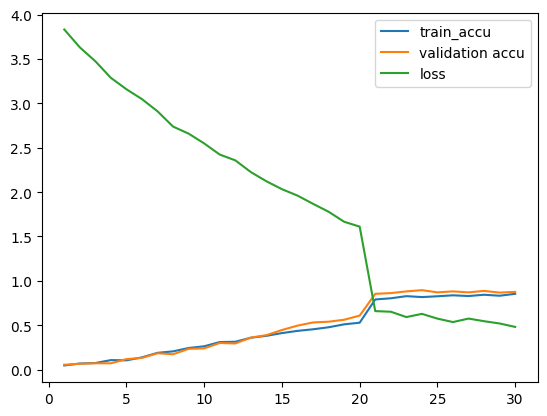

In [27]:
import matplotlib.pyplot as plt
plt.plot(range(1,31),r.history['accuracy']+ r2.history['accuracy'],label='train_accu')
plt.plot(range(1,31),r.history['val_accuracy'] + r2.history['val_accuracy'],label='validation accu')
plt.plot(range(1,31),r.history['loss'] + r2.history['loss'],label = "loss")

plt.legend()
plt.show()

**Interpretation**

✔ Model is learning meaningful gesture features

✔ No severe overfitting

✔ Validation accuracy being higher means augmentations are effective

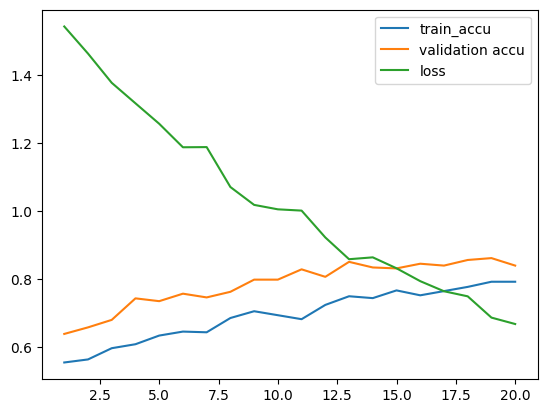

In [ ]:
# import matplotlib.pyplot as plt
# plt.plot(range(1,21),r2.history['accuracy'],label='train_accu')
# plt.plot(range(1,21),r2.history['val_accuracy'],label='validation accu')
# plt.plot(range(1,21),r2.history['loss'],label = "loss")
# plt.legend()
# plt.show()

In [ ]:
#model.save("final_exported_model02.keras")

In [3]:
# from tensorflow.keras.models import load_model

# model = load_model(r"C:\Users\M NANDAGOPAL\OneDrive\Desktop\project_cnn\AMERICAN SIGN LANGUAGE\final_exported_model02.keras")
# model.save("final_exported_model03.h5")

from tensorflow.keras.models import load_model

model = load_model(r"C:\Users\M NANDAGOPAL\OneDrive\Desktop\project_cnn\AMERICAN SIGN LANGUAGE\final_exported_model02.keras", compile=False)
model.save("final_exported_model04.h5", include_optimizer=False)